# Exercise 4

Nhu Dat Cao, Javier Utrilla Vázquez

# 1. Constructing the matrix X

<div style="color: green; font-weight: bold">
The overall projection logic is correct and follows the same principle as the sample solution. Therefore, for the core algorithm, both implementations are essentially equivalent in terms of the underlying mathematical model.

Note that, in your solution, a separate mask is used for `left` and `right` indices, while the sample solution uses a single combined `clip` mask ensuring that only valid sensor ranges `[0, Np-1)` contribute. The sample approach is slightly more robust because it guarantees consistency between paired contributions (left/right weights) and avoids partial inclusion where only one side is valid. In contrast, the separate masking can potentially allow one-sided contributions near boundaries, which may introduce minor inconsistencies in edge cases.

The computation of grid coordinates using `np.mgrid` and explicit centering is correct, but it is slightly more manual compared to the sample solution's use of a reshaped meshgrid. Both approaches are valid implementations of the same coordinate construction, but the sample version is more compact.
</div>

In [1]:
import numpy as np
from scipy.sparse import coo_matrix


def construct_X(M, alphas, Np=None):
    """
    Construct the projection matrix X using
    the proposed sparsity and vectorization.

    M : image size D = M x M
    alphas : projection angles in degrees
    Np : number of sensor bins

    Returns
        X : sparse projection matrix of shape
        (len(alphas)*Np, M*M).
    """

    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
        if Np % 2 == 0:
            Np += 1 # ideally odd

    No = len(alphas)
    D = M * M
    N = No * Np

    # ----------------------------------------------
    # pixels
    # ----------------------------------------------

    a, b = np.mgrid[0:M, 0:M]

    # image center is the origin
    a = a.astype(np.float32) - (M - 1) / 2
    b = b.astype(np.float32) - (M - 1) / 2

    # flatten as j = ja + M*jb
    C = np.vstack([
        a.ravel(order="F"),
        b.ravel(order="F")
    ])

    cols = np.arange(D, dtype=np.int32)

    # sensor origin shift
    s0 = (Np - 1) / 2

    all_rows = []
    all_cols = []
    all_weights = []

    # ------------------------------------------------
    # projection angles
    # -------------------------------------------------

    for io, alpha in enumerate(alphas):

        theta = np.deg2rad(alpha)

        n = np.array([
            np.cos(theta),
            -np.sin(theta)
        ], dtype=np.float32)

        p = n @ C + s0

        # calculate intensity percentage
        left = np.floor(p).astype(np.int32)
        right = left + 1

        w_right = p - left
        w_left = 1.0 - w_right

        # append in order 

        mask_left = (left >= 0) & (left < Np)
        rows_left = left[mask_left] + io * Np

        all_rows.append(rows_left)
        all_cols.append(cols[mask_left])
        all_weights.append(w_left[mask_left])

        mask_right = (right >= 0) & (right < Np)
        rows_right = right[mask_right] + io * Np

        all_rows.append(rows_right)
        all_cols.append(cols[mask_right])
        all_weights.append(w_right[mask_right])

    # -------------------------------------------------
    # sparese matrix
    # -------------------------------------------------

    i_indices = np.concatenate(all_rows)
    j_indices = np.concatenate(all_cols)
    weights = np.concatenate(all_weights).astype(np.float32)

    X = coo_matrix(
        (weights, (i_indices, j_indices)),
        shape=(N, D),
        dtype=np.float32
    )

    return X

We can check now the matrix construction:

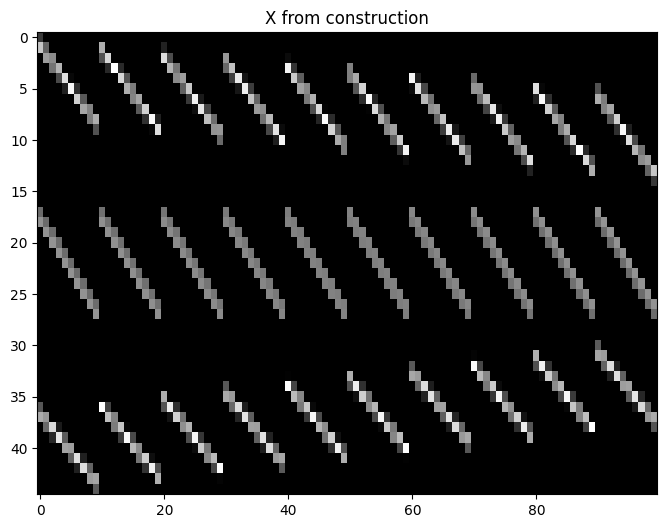

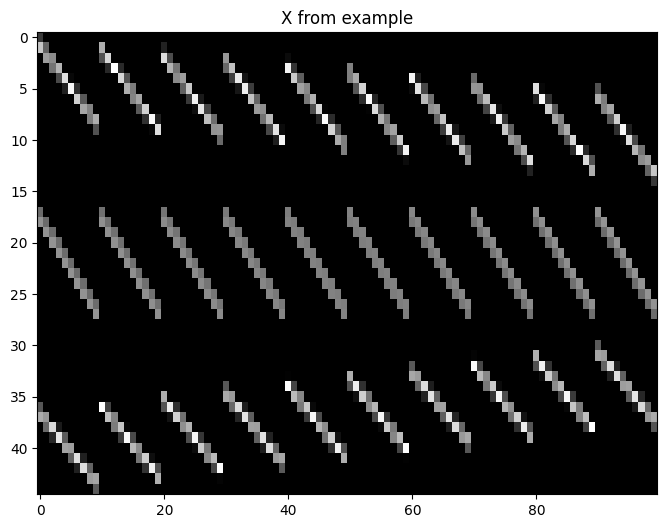

Matrix difference:  7.1525574e-07


In [2]:
import matplotlib.pyplot as plt

X = construct_X(
    M=10,
    alphas=[-33, 1, 42]
)

plt.figure(figsize=(8, 6))
plt.title('X from construction')
plt.imshow(X.toarray(), aspect="auto", cmap='gray')
plt.show()

X_example = np.load('hs_tomography/X_example.npy')

plt.figure(figsize=(8, 6))
plt.title('X from example')
plt.imshow(X_example, aspect="auto", cmap='gray')
plt.show()

print('Matrix difference: ', np.max(np.abs(X - X_example)))

We can see they are essentially the same. Appart from the visualization we compute the maximum difference between matrix elements (7.15e-7), which falls under numerical tolerance range.

# 2. Recovering the image

In [3]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

DATA = "hs_tomography"


def report_sparsity(X):
    # count the real non-zeros: a ray that lands exactly on a bin centre
    # stores a 0 weight, so drop those first or nnz comes out too high
    Xc = sp.csc_matrix(X, copy=True)
    Xc.eliminate_zeros()
    nnz = Xc.nnz
    total = Xc.shape[0] * Xc.shape[1]
    print(f"non-zeros {nnz} / {total}, sparsity {1 - nnz / total:.6f}")
    return nnz


def reconstruct(X, y, M, atol=1e-5, btol=1e-5):
    # solve the sparse least-squares system X @ beta = y, then reshape the
    # flat solution (j = ja + M*jb) back into an M x M tomogram
    beta = spla.lsqr(X, y, atol=atol, btol=btol)[0]
    return beta.reshape(M, M)

Small version first (M=77), recommended for debugging.

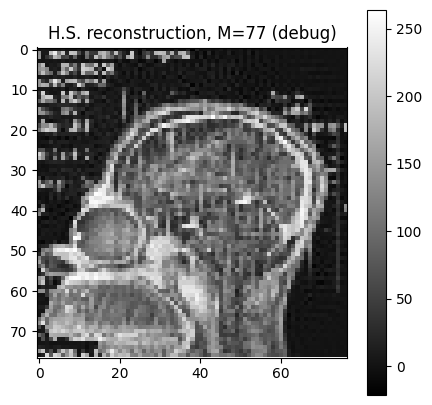

In [4]:
# start with the small data so we can check the head is recognisable
M77, Np77 = 77, 109
alphas_77 = np.load(f"{DATA}/alphas_77.npy")
y_77 = np.load(f"{DATA}/y_77.npy")

# build X with construct_X from task 1 and reconstruct the image
X_77 = sp.csc_matrix(construct_X(M77, alphas_77, Np77))
img77 = reconstruct(X_77, y_77, M77)

plt.figure(figsize=(5, 5))
plt.imshow(img77, cmap="gray")
plt.title("H.S. reconstruction, M=77 (debug)")
plt.colorbar()
plt.show()

Full resolution (M=195) for the actual diagnosis. The sparsity below answers how many non-zero entries X has.

non-zeros 13535845 / 1871780625, sparsity 0.992768


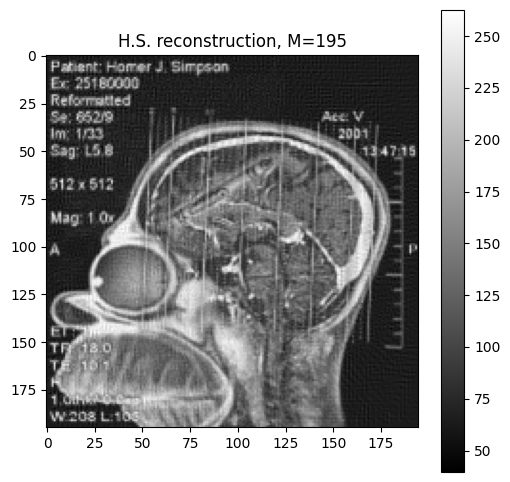

In [5]:
# now the full-resolution data, this is the one we diagnose on
M195, Np195 = 195, 275
alphas_195 = np.load(f"{DATA}/alphas_195.npy")
y_195 = np.load(f"{DATA}/y_195.npy")

X_195 = sp.csc_matrix(construct_X(M195, alphas_195, Np195))

# exactly how many non-zeros does X have, and how sparse is it?
report_sparsity(X_195)

img195 = reconstruct(X_195, y_195, M195)
plt.figure(figsize=(6, 6))
plt.imshow(img195, cmap="gray")
plt.title("H.S. reconstruction, M=195")
plt.colorbar()
plt.show()

## Diagnosis and treatment

The M=195 reconstruction is a clean sagittal slice of the patient's head (annotated
`Patient: Homer J. Simpson`). Observations:
- the skull forms a bright, intact ring of high absorption - no fracture and no acute bleeding;
- no high-absorption foreign body or mass lesion is visible inside the cranium;
- the brain tissue fills only a small part of the cranial cavity, the remainder being
  low-absorption (dark) space, i.e. an unusually small brain.

Diagnosis: there is no structural emergency (no haemorrhage, tumour or fracture); the notable
finding is the small brain volume relative to the skull.

Treatment: reassurance and conservative symptomatic care (rest, hydration, over-the-counter
analgesics). No surgery or contrast imaging is indicated.

# 3. Minimizing the radiation dose

In [6]:
def even_indices(No, n):
    # choose n angles spread evenly over all orientations;
    # spreading them out covers more directions than a contiguous block
    return np.unique(np.linspace(0, No - 1, n).round().astype(int))


def subsample(X, y, Np, sel):
    # keep only the rows that belong to the chosen angles.
    # orientation io owns the Np rows [io*Np : (io+1)*Np] in X and y
    rows = np.concatenate([np.arange(io * Np, (io + 1) * Np) for io in sel])
    return X[rows], y[rows]

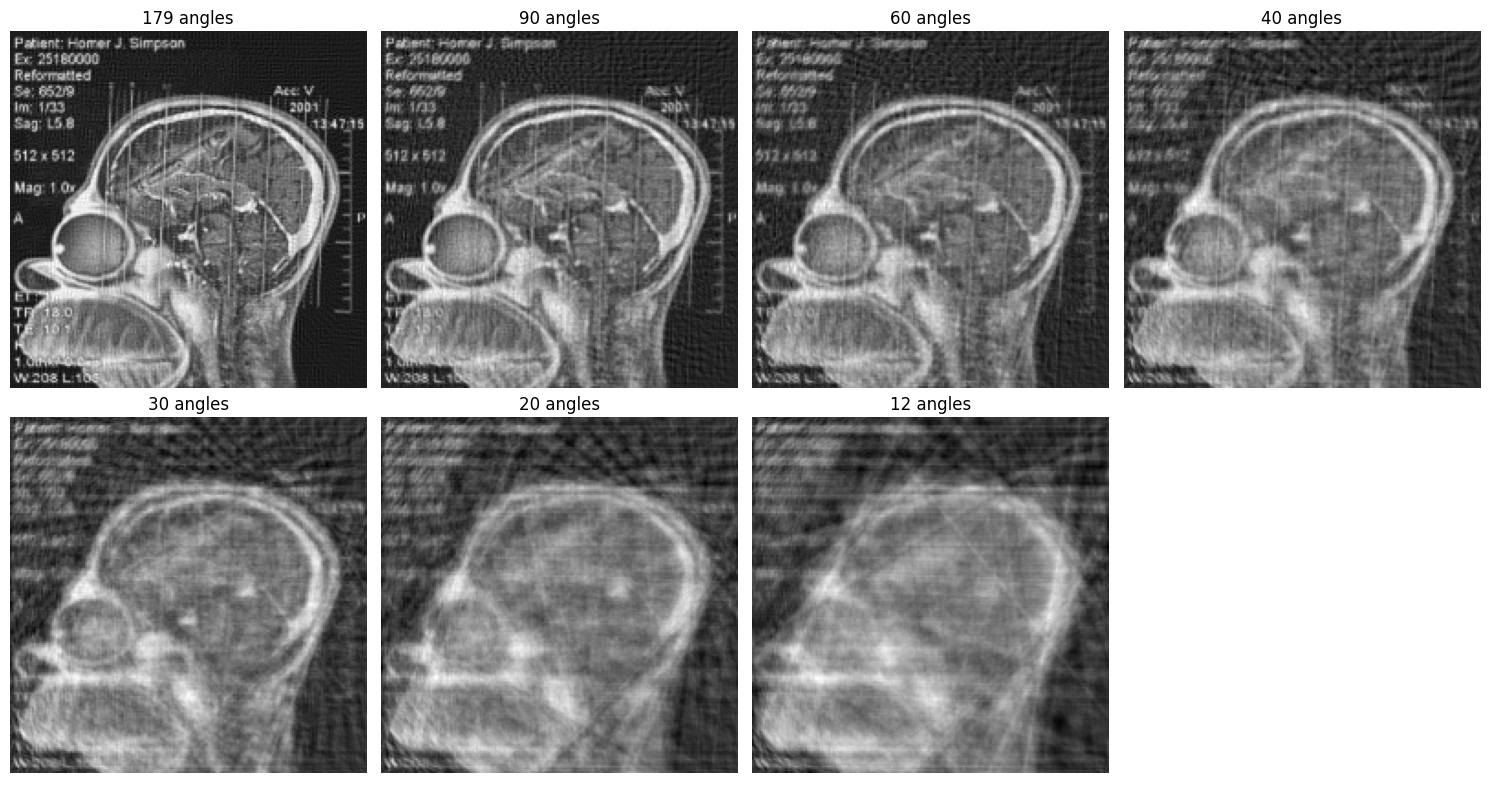

In [7]:
# reconstruct from fewer and fewer angles to see how far we can cut the dose
counts = [179, 90, 60, 40, 30, 20, 12]
imgs = {}
for n in counts:
    sel = even_indices(len(alphas_195), n)
    Xs, ys = subsample(X_195, y_195, Np195, sel)
    imgs[len(sel)] = reconstruct(Xs, ys, M195)

# show all reconstructions next to each other
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, n in zip(axes.ravel(), sorted(imgs, reverse=True)):
    ax.imshow(imgs[n], cmap="gray")
    ax.set_title(f"{n} angles")
    ax.axis("off")
axes.ravel()[-1].axis("off")  # hide the empty 8th panel
plt.tight_layout()
plt.show()

 12 angles  rel. L2 error 0.2135
 20 angles  rel. L2 error 0.1907
 30 angles  rel. L2 error 0.1640
 40 angles  rel. L2 error 0.1432
 60 angles  rel. L2 error 0.1143
 90 angles  rel. L2 error 0.0840
179 angles  rel. L2 error 0.0000


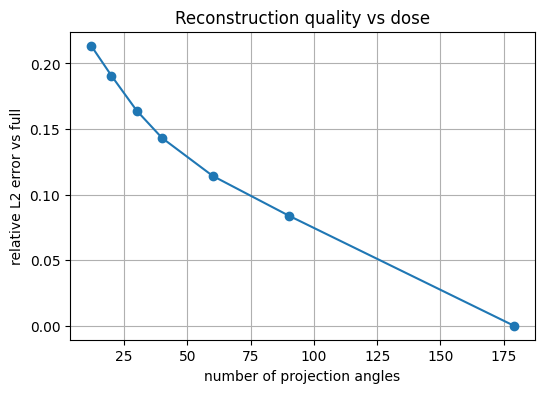

In [8]:
# quantify quality as the relative L2 difference to the full-angle reconstruction
full = imgs[max(imgs)]
ns = sorted(imgs)
err = [np.linalg.norm(imgs[n] - full) / np.linalg.norm(full) for n in ns]
for n, e in zip(ns, err):
    print(f"{n:3d} angles  rel. L2 error {e:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(ns, err, "o-")
plt.xlabel("number of projection angles")
plt.ylabel("relative L2 error vs full")
plt.title("Reconstruction quality vs dose")
plt.grid(True)
plt.show()

## Minimal number of projections

Using evenly spaced subsets of the 179 angles, the reconstruction stays sharp down to about 90
angles and is still diagnostically clear at roughly 60 (relative L2 error ~0.11). At 40 angles it
is borderline; below about 30 the internal structures dissolve into streak artefacts and the
cause can no longer be resolved. We therefore estimate the minimal number of projections at
around 60 - roughly one third of the original 179, cutting the radiation dose about threefold
while still resolving the cause.